# Imports

In [30]:
import yaml
import numpy as np
from functools import partial
import astromet
import gaiascanlaw
from copy import deepcopy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import sys
sys.path.append('../inference')
import utils
from utils import astrometry_sim

from cmap import Colormap
cm = Colormap('tol:muted')

# Plot settings

In [3]:
import scienceplots
import matplotlib as mpl
from matplotlib import pyplot as plt

plt.style.use('science')
plt.rc('text', usetex=plt.rcParamsDefault['text.usetex'])
mpl.rcParams['font.size'] = 16
mpl.rcParams['figure.figsize'] = (8,6)
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['xtick.major.size'] = 7
mpl.rcParams['ytick.major.size'] = 7

mpl.rcParams['xtick.minor.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.5
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.minor.size'] = 5

In [4]:
color_median = '#882255'
color_sample = '#FFAABB'
gaia_color = '#337788'
gaia_in_color = '#77AADD'

model_ccycler = [gaia_color, color_median]
model_icycler = [gaia_in_color, color_sample]

# Load and plot data

Just like in the `Gaia_mock_data_hands_on` tutorial, let's load in a dataset for our event.

This time, we will choose an event with a black hole lens and a bright baseline - optimal for mass determination!

In [35]:
source_path = 'BH303396S5317045714310660096'

In [38]:
data_filename = f'../data/{source_path}.npy'
true_filename = f'../data/{source_path}_true_params.npy'
fit_filename = f'../data/{source_path}_5p_fit_DR4.npy'

In [39]:
data = np.load(data_filename, allow_pickle='TRUE').item()
true_params = np.load(true_filename, allow_pickle='TRUE').item()
fit_results = np.load(fit_filename, allow_pickle='TRUE').item()

# Model parameters

A most typical, single _Gaia_ source has a constant magnitude $G_0$ and a 5-parameter solution: $\alpha_0, \delta_0, \mu_{\alpha*}, \mu_\delta, \varpi$. <span style="color:blue">$\rightarrow$ 6 parameters</span>


The lightcurve contains microlensing signal added to the constant baseline $G_0$, which can be described as a function of the microlensing parameters $t_0$ (closest approach time in linear lens-source motion), $u_0$ (impact parameter), $t_E$ (Einstein time - the event's timescale) and $\vec{\pi_E}$ (which we parameterize by magnitude $\pi_E$ and direction $\phi$) <span style="color:blue">$\rightarrow$ 5 parameters</span>

The astrometric time series also contain microlensing signal added to the 5-parameter path. Its shape is a function of the same parameters, and its amplitude is scaled by the $\theta_E$ (angular Einstein radius - the event's on-sky angular scale). $\theta_E$ is a parameter not measurable from photometry, but crucial for determining mass. <span style="color:blue">$\rightarrow$ 1 parameter</span>

Therefore, we will fit a total of <span style="color:blue">12 parameters.</span>

As we are dealing with very small (~milliarcseconds) deviations from the reference position, it would be inconvenient to fit $\alpha_0, \delta_0$ anew. Instead, we will fit the difference between the true (unlensed) source reference position and that initially reported by _Gaia_ when fitting a 5-parameter solution: $\Delta\alpha_0, \Delta\delta_0$.

<span style="color:green">$\theta_E$</span>, <span style="color:green">$t_E$</span> and <span style="color:green">$\pi_E$</span> are especially interesting parameters, as they are tied to the physical properties of the lens.

The lens mass can be calculated as: 
$$M_{L} = \frac{\color{green}{\theta_{E}}}{\kappa \color{green}{\pi_{E}}},$$

where $\kappa$ is a constant.



# Prepare inference routines

Now we want to get the parameters of the black hole. This is just like the `inference/fit_model.py` contents, but inside an interactive notebook.

Firstly, we'll prepare the input for nested sampling. The `config` file specifies settings of our inference: priors for the parameters we're fitting, an output directory where we will store results, and the number of live points `nlive` we will use.

The higher `nlive` we use, the higher the resolution with which we probe the parameter space. That comes at the cost of computing time. For the purpose of this demonstration, we will use a relatively low `nlive` of 100.

In [8]:
with open("../inference/config.yaml", "r") as file:
    base_config = yaml.load(file, Loader=yaml.SafeLoader)
    
output_dir = base_config["paths"]["output_directory"]

We also need a log-likelihood function that we will be maximizing. This is defined in `utils` with a simple Gaussian PDF - we just need to plug in our data and errors:

In [9]:
log_likelihood = partial(utils.log_likelihood, obsdata=data)

When the impact parameter (lens-source separation scaled by $\theta_E$) $u_0 \rightarrow 0$, the amplification approaches infinity. This leads to unstable behaviour and can sometimes get our inference code stuck for a long time exploring some very implausible solutions when crossing the $u_0 = 0$ boundary.

To avoid it, we're going to run our inference twice, for strictly defined positive and negative $u_0$ bounds. The function below is a routine for running the inference code for a given $u_0$ sign and output subdirectory.

In [10]:
def run_solution(u0_sign, output_suffix,
    base_config=base_config, output_dir=output_dir, data=data, source_id=source_id, log_likelihood=log_likelihood):

    config_tmp = deepcopy(base_config) # we will update the base config
    output_path_tmp = output_dir + output_suffix
    config_tmp["paths"]["output_directory"] = output_path_tmp # the samples will be saved in a specified subdirectory
    config_tmp["priors"]["u0"]["parameters"]["sign"] = u0_sign # and we specify the u0 sign

    # We get all priors as specified in the "priors" part of the config:
    priors = utils.get_all_priors(config=config_tmp, obsdata=data)
    prior_transform = partial(utils.prior_transform, priors=priors)

    # We find posterior distributions with nested sampling, given the priors and a log-likelihood function
    dynesty_results = utils.run_dynesty_sampling(log_likelihood, prior_transform, config_tmp)
    # and save the resulting samples right away.
    utils.save_dynesty_results(results=dynesty_results, source_id=source_id, config=config_tmp)

    # Now we can load pre-saved dynesty samples (size=None means we load all samples available).
    print(f"{output_path_tmp}{source_id}_dynesty.pkl")
    posterior = utils.get_posterior_samples(source_id=source_id, path=output_path_tmp, size=None)

    # The metric by which we will evaluate the solution is the median log-likelihood of samples:
    median_logl = np.median(dynesty_results.logl)

    return median_logl

# Run inference and get samples

We will now run the nested sampling routine - this can take a few minutes, so you can make a coffee and come back! :)

Positive $u_0$:

In [11]:
median_logl_pos = run_solution(1, "run_positive/")

23512it [05:08, 76.30it/s, batch: 10 | bound: 8 | nc: 1 | ncall: 726193 | eff(%):  3.170 | loglstar: 4618.219 < 4630.256 < 4627.743 | logz: 4551.489 +/-  0.347 | stop:  0.727]               

../results/run_positive/BH303396S5317045714310660096_dynesty.pkl


Negative $u_0$:

In [12]:
median_logl_neg = run_solution(-1, "run_negative/")

18661it [04:04, 76.32it/s, batch: 7 | bound: 1 | nc: 1 | ncall: 569354 | eff(%):  3.191 | loglstar: 1127.696 < 1136.508 < 1128.327 | logz: 1059.510 +/-  0.351 | stop:  0.965]                 


../results/run_negative/BH303396S5317045714310660096_dynesty.pkl


We're going to choose the solution with the higher log-likelihood and load the samples from `dynesty`:

In [13]:
if median_logl_pos > median_logl_neg:
    solution_path = output_dir + "run_positive/"
else:
    solution_path = output_dir + "run_negative/"

posterior = utils.get_posterior_samples(source_id=source_id, path=solution_path, size=None)

# Explore model fits

Let's see what parameters have been chosen, and how they compare to the injected parameters used to create this mock dataset!

First, we will create a corner plot:

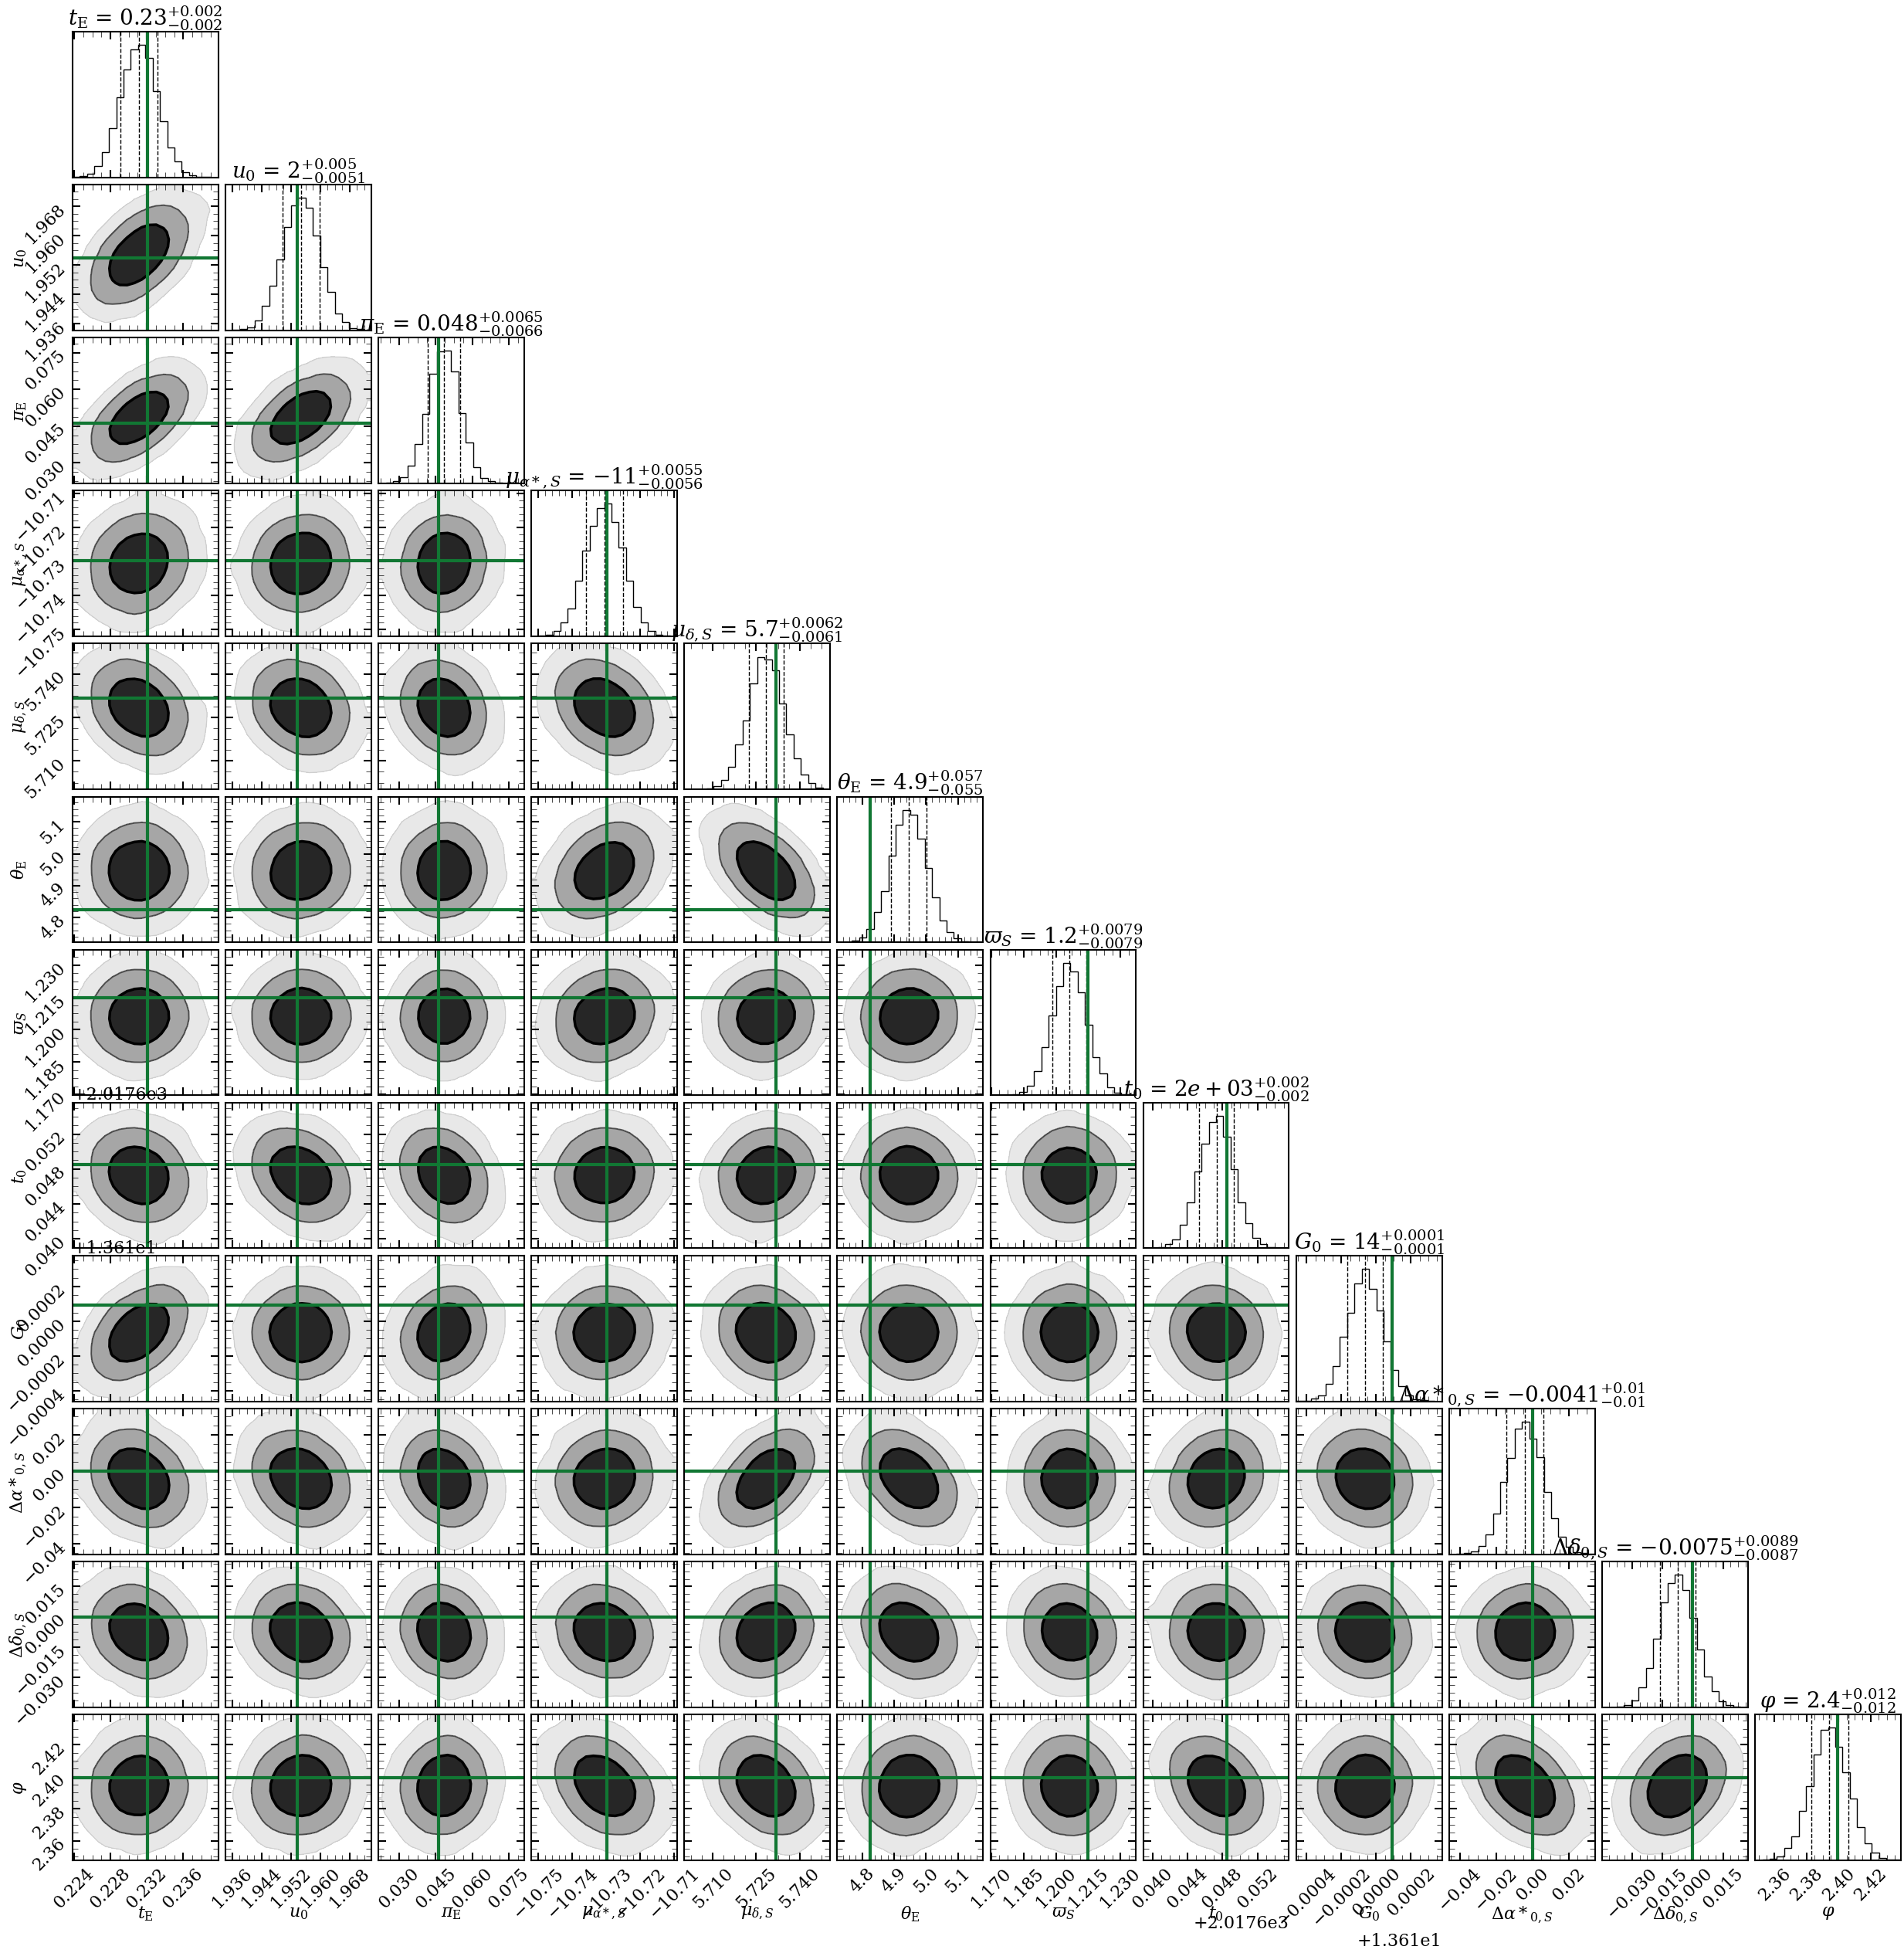

In [16]:
import matplotlib.pyplot as plt
import corner
fig = plt.figure(figsize=(25, 25))

param_names = list(posterior.keys())
samples_array = np.array([posterior[param] for param in param_names]).T

labels = [r'$t_{\rm E}$', r'$u_0$', r'$\pi_{\rm E}$', r'$\mu_{\alpha*, S}$', r'$\mu_{\delta, S}$', r'$\theta_{\rm E}$', r'$\varpi_S$', r'$t_0$', r'$G_0$', r'$\Delta\alpha*_{0, S}$', r'$\Delta\delta_{0, S}$', r'$\varphi$']


figure = corner.corner(samples_array, labels=labels,
                           quantiles=[0.16, 0.5, 0.84],
                           show_titles=True, title_kwargs={"fontsize": 20},
                           title_fmt=".2g",
                           smooth=1.0,
                           fig=fig,
                           range = [1. for i in range(12)],
                           levels=(0.68, 0.95, 0.997),
                           contourf_kwargs={"colors": [
                                    (0, 0, 0, 0.0),
                                    (0, 0, 0, 0.09),
                                    (0, 0, 0, 0.35),
                                    (0, 0, 0, 0.85),]},
                           contour_kwargs={"colors": [(0, 0, 0, 0.11), (0, 0, 0, 0.5), (0, 0, 0, 1)],"linewidths": [1.0, 1.5, 2.5],},
                           plot_density=False,
                           plot_datapoints=False,
                           fill_contours=True)



if true_params is not None:
    true_values = []
    for param in param_names:
            if param=='phi':
                true_values.append(true_params[param]%(2*np.pi))
            else:
                true_values.append(true_params[param])
    corner.overplot_lines(figure, true_values, color=cm(3), lw=3)

...and see that our posterior distributions reproduce the true parameters very nicely!

Let's also check how consistent our model fit is with the mock astrometric time series. We will use the median parameters from all samples:

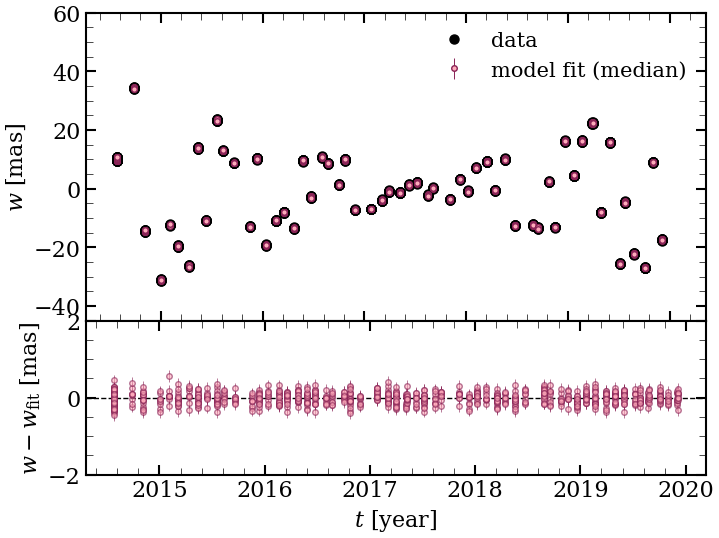

In [63]:
pmrac_S_med, pmdec_S_med, varpi_S_med, alpha0_S_med, delta0_S_med = np.median(posterior['pmrac_S']), np.median(posterior['pmdec_S']), np.median(posterior['varpi_S']), np.median(posterior['alpha0_S']), np.median(posterior['delta0_S'])
tE_med, u0_med, piE_med, thetaE_med, t0_med, m0_med, phi_med = np.median(posterior['tE']), np.median(posterior['u0']), np.median(posterior['piE']), np.median(posterior['thetaE']), np.median(posterior['t0']), np.median(posterior['m0']), np.median(posterior['phi'])

# load transit data
time, sc_a, fw, fz, refEpoch, wObs, wErr = data['time'], data['sc_a'], data['fw'], data['fz'], data['refEpoch'], data['w'], data['wError']
ws_med, mags_med = astrometry_sim(
                time, time-refEpoch, sc_a, fw, fz,
                tE_med, u0_med, piE_med, pmrac_S_med, pmdec_S_med, thetaE_med, varpi_S_med, t0_med, m0_med, alpha0_S_med, delta0_S_med, phi_med)


fig, axes = plt.subplots(2, 1, height_ratios=(2, 1))
plt.subplots_adjust(hspace=0)
ax_w, ax_w_res = axes[0], axes[1]

ax_w.errorbar(time, wObs, c='k', 
                 zorder=2, fmt='.', ms=13, elinewidth=0.7, alpha=1, label='data')
ax_w.errorbar(time, wObs, yerr=wErr, ecolor=color_median, markerfacecolor=color_sample, markeredgecolor=color_median, 
                 zorder=2, fmt='.', ms=8, elinewidth=0.7, alpha=1, label='model fit (median)')
ax_w_res.errorbar(time, wObs - ws_med, yerr=wErr, ecolor=color_median, markerfacecolor=color_sample, markeredgecolor=color_median, 
                 zorder=2, fmt='.', ms=8, elinewidth=0.7, alpha=0.6)

tstart=gaiascanlaw.tstart
tend=gaiascanlaw.tdr4

ax_w_res.set_xlabel(r'$t$ [year]')
ax_w.set_ylabel(r'$w$ [mas]')
ax_w_res.set_ylabel(r'$w - w_{\text{fit}}$ [mas]')

ax_w.set_xlim(tstart - 0.3, tend + 0.3)
ax_w_res.set_ylim(-2, 2)
ax_w.set_ylim(-45, 60)

ax_w_res.axhline(y=0, ls='--', c='k', lw=1)
ax_w.legend(loc='best', fontsize=15)

For comparison, we can also overplot the Gaia 5-parameter solution:

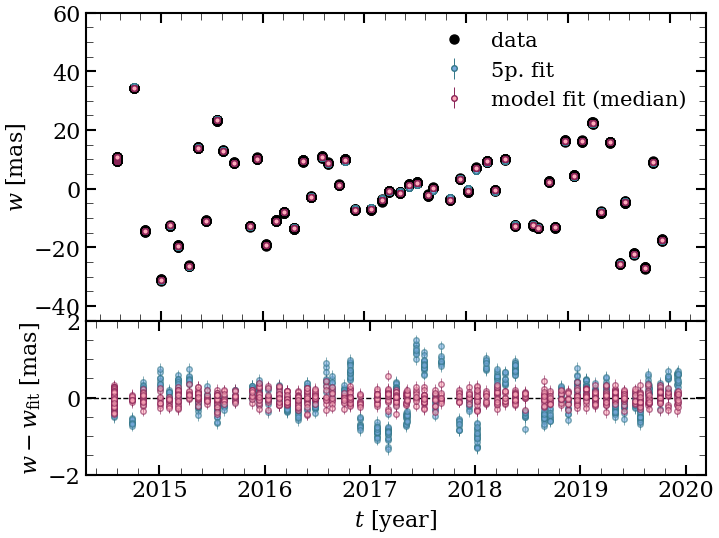

In [60]:
# Get ws from 5p. fit
p5p = astromet.params()
p5p.epoch = 2017.5
p5p.drac, p5p.ddec, p5p.parallax, p5p.pmrac, p5p.pmdec, p5p.ra, p5p.dec = fit_results['drac'], fit_results['ddec'], fit_results['parallax'], fit_results['pmrac'], fit_results['pmdec'], fit_results['ra_ref'], fit_results['dec_ref']
ts_unique = data['time'].reshape(int(data['time'].shape[0]/9), 9).T[0]
sc_a_unique = data['sc_a'].reshape(int(data['sc_a'].shape[0]/9), 9).T[0]
racs, decs = astromet.track(ts_unique, p5p)
t_obs, x_obs, phi_obs, rac_obs, dec_obs = astromet.mock_obs(ts_unique, sc_a_unique, racs, decs, err=np.zeros_like(time))


ws = [x_obs, ws_med]

fig, axes = plt.subplots(2, 1, height_ratios=(2, 1))
plt.subplots_adjust(hspace=0)
ax_w, ax_w_res = axes[0], axes[1]

labels = ['5p. fit', 'model fit (median)']


ax_w.errorbar(time, wObs, c='k', 
                 zorder=2, fmt='.', ms=13, elinewidth=0.7, alpha=1, label='data')

i=0
for w_model in ws:

    ax_w.errorbar(time, w_model, yerr=wErr, ecolor=model_ccycler[i], markerfacecolor=model_icycler[i], markeredgecolor=model_ccycler[i], 
                 zorder=2, fmt='.', ms=8, elinewidth=0.7, alpha=1, label=labels[i])

    ax_w_res.errorbar(time, wObs - w_model, yerr=wErr, ecolor=model_ccycler[i], markerfacecolor=model_icycler[i], markeredgecolor=model_ccycler[i], 
                 zorder=2, fmt='.', ms=8, elinewidth=0.7, alpha=0.6)
    i+=1

ax_w_res.set_xlabel(r'$t$ [year]')
ax_w.set_ylabel(r'$w$ [mas]')
ax_w_res.set_ylabel(r'$w - w_{\text{fit}}$ [mas]')

ax_w.set_xlim(tstart - 0.3, tend + 0.3)
ax_w_res.set_ylim(-2, 2)
ax_w.set_ylim(-45, 60)

ax_w_res.axhline(y=0, ls='--', c='k', lw=1)
ax_w.legend(loc='best', fontsize=15)

We can clearly see that including the effect of lensing by a black hole has improved our solution a lot!

# Get black hole mass

Now, only the most exciting part is left! We will use $\theta_E$ and $\pi_E$ to get the black hole mass:

In [64]:
mass_samples = posterior['thetaE']/(8.144*posterior['piE'])
mass_50, mass_ll, mass_ul = np.percentile(mass_samples, 50), np.percentile(mass_samples, 16), np.percentile(mass_samples, 84)

In [65]:
true_mass = true_params['thetaE']/(8.144*true_params['piE']) 

In [66]:
from IPython.display import display, Math, Markdown 
display(Markdown("Inferred mass: "))
display(Math(rf"${round(mass_50,2)}_{{-{round(mass_50 - mass_ll,2)}}}^{{+{round(mass_ul - mass_50,2)}}} \ M_\odot$"))
display(Markdown("True mass: "))
display(Math(rf"${round(true_mass,2)}\ M_\odot$"))

Inferred mass: 

<IPython.core.display.Math object>

True mass: 

<IPython.core.display.Math object>